# Game Theory for Portfolio Optimization: Identification Step

Notebook ini mengimplementasikan rencana identifikasi Game Theory untuk optimasi portofolio berdasarkan dokumen `Rencana_Game_Theory_Identification.md`.

## Tujuan
1. Mengambil data historis dua aset (Leader & Follower).
2. Mengidentifikasi state pasar (Naik/Turun) yang diasosiasikan dengan state kuantum.
3. Menghitung Payoff Matrix untuk analisis Game Theory.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi Visualisasi
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Persiapan dan Analisis Data
Mengambil data historis untuk 2 saham, misalnya **GOOGL** (Leader) dan **TSLA** (Follower).

In [2]:
# Parameter
tickers = ['GOOGL', 'TSLA']
leader = 'GOOGL'
follower = 'TSLA'
start_date = '2020-01-01'
end_date = '2024-01-01'

# Download Data
print(f"Downloading data for {tickers}...")
data_full = yf.download(tickers, start=start_date, end=end_date)

# Check for Adj Close or Close
if 'Adj Close' in data_full.columns.get_level_values(0):
    data = data_full['Adj Close']
elif 'Close' in data_full.columns.get_level_values(0):
    data = data_full['Close']
else:
    raise ValueError("Neither 'Adj Close' nor 'Close' found in downloaded data.")

data.dropna(inplace=True)

print(data.head())

[*********************100%***********************]  2 of 2 completed

Ticker          GOOGL       TSLA
Date                            
2020-01-02  67.920807  28.684000
2020-01-03  67.565483  29.534000
2020-01-06  69.366386  30.102667
2020-01-07  69.232399  31.270666
2020-01-08  69.725174  32.809334



Matriks Korelasi:
Ticker     GOOGL      TSLA
Ticker                    
GOOGL   1.000000  0.846524
TSLA    0.846524  1.000000


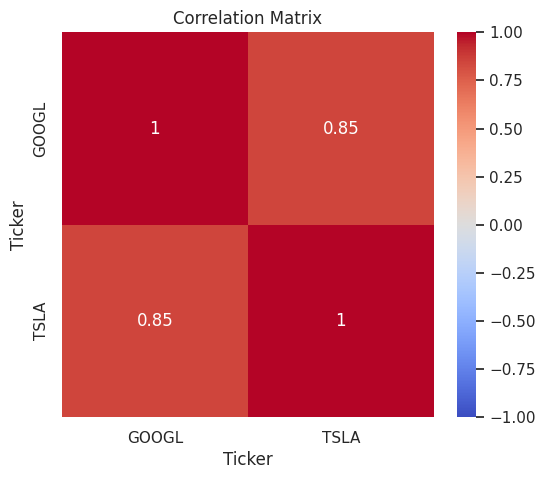

In [3]:
# Analisis Korelasi Pearson
correlation = data.corr(method='pearson')
print("\nMatriks Korelasi:")
print(correlation)

plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

## 2. Klasifikasi State Market (Binarisasi)
Return dihitung sebagai Log Return. State pasar diklasifikasikan menjadi:
- **0 (Naik)**: Return $>$ 0
- **1 (Turun)**: Return $\ge$ 0

Kemudian kita bentuk pasangan state (Leader, Follower), misal `01`.

In [4]:
# Hitung Daily Log Return
returns = np.log(data / data.shift(1)).dropna()

# Fungsi Binarisasi
def bin_state(val):
    return 0 if val > 0 else 1

# Terapkan Binarisasi
market_states = pd.DataFrame()
market_states[leader] = returns[leader].apply(bin_state)
market_states[follower] = returns[follower].apply(bin_state)

# Gabungkan state menjadi string "LeaderFollower"
# 00: L Up, F Up
# 01: L Up, F Down
# 10: L Down, F Up
# 11: L Down, F Down
market_states['state'] = market_states[leader].astype(str) + market_states[follower].astype(str)

combined_data = pd.concat([returns, market_states['state']], axis=1)
print("Sample Data dengan State:")
print(combined_data.head())

Sample Data dengan State:
               GOOGL      TSLA state
Date                                
2020-01-03 -0.005245  0.029203    10
2020-01-06  0.026305  0.019072    00
2020-01-07 -0.001933  0.038067    10
2020-01-08  0.007092  0.048033    00
2020-01-09  0.010443 -0.022189    01


## 3. Perhitungan Payoff
Menghitung payoff rata-rata untuk Leader dan Follower pada setiap state.
Rumus Payoff:
$$ \text{Payoff} = \frac{\sum \text{Return}}{n - 1} $$
Dimana $n$ adalah frekuensi kejadian state tersebut.

In [5]:
# Hitung frekuensi setiap state
state_counts = combined_data['state'].value_counts()
print("\nFrekuensi State:")
print(state_counts)

# Inisialisasi Dictionary untuk Payoff
payoffs = {
    '00': {'L': 0, 'F': 0},
    '01': {'L': 0, 'F': 0},
    '10': {'L': 0, 'F': 0},
    '11': {'L': 0, 'F': 0}
}

for state in payoffs.keys():
    if state in state_counts:
        n = state_counts[state]
        if n > 1:
            # Filter data untuk state ini
            subset = combined_data[combined_data['state'] == state]
            
            # Sum returns
            sum_L = subset[leader].sum()
            sum_F = subset[follower].sum()
            
            # Hitung Payoff (Average / Normalized)
            payoffs[state]['L'] = sum_L / (n - 1)
            payoffs[state]['F'] = sum_F / (n - 1)

print("\nHasil Perhitungan Payoff:")
for s, p in payoffs.items():
    print(f"State {s}: Leader ({leader}) = {p['L']:.6f}, Follower ({follower}) = {p['F']:.6f}")


Frekuensi State:
state
00    370
11    298
10    170
01    167
Name: count, dtype: int64

Hasil Perhitungan Payoff:
State 00: Leader (GOOGL) = 0.015496, Follower (TSLA) = 0.033365
State 01: Leader (GOOGL) = 0.013468, Follower (TSLA) = -0.022455
State 10: Leader (GOOGL) = -0.011997, Follower (TSLA) = 0.024841
State 11: Leader (GOOGL) = -0.017551, Follower (TSLA) = -0.035769


## 4. Analisis & Output Matriks Payoff
Menampilkan matriks payoff dalam bentuk tabel dan heatmap untuk interpretasi Game Theory.

| L \ F | 0 (Naik) | 1 (Turun) |
| :---: | :---: | :---: |
| **0 (Naik)** | $a, b$ | $c, d$ |
| **1 (Turun)** | $e, f$ | $g, h$ |


Payoff Matrix Leader (GOOGL):
 [[ 0.01549574  0.01346782]
 [-0.01199654 -0.01755089]]

Payoff Matrix Follower (TSLA):
 [[ 0.03336511 -0.0224553 ]
 [ 0.02484144 -0.03576877]]


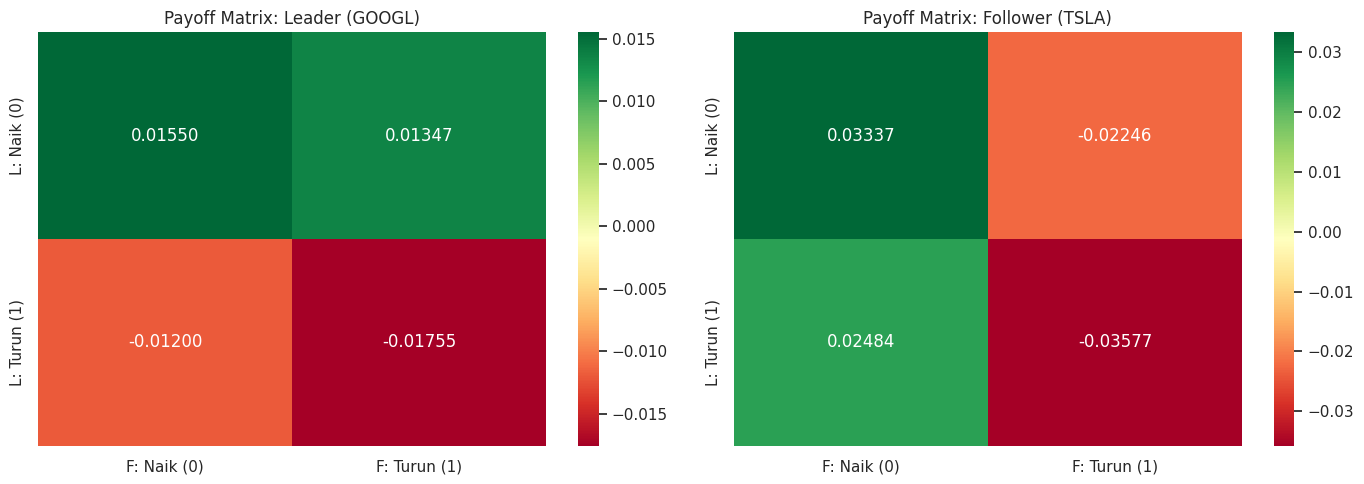

In [6]:
# Konstruksi Matriks Payoff 2x2
# Row 0: Leader Naik, Row 1: Leader Turun
# Col 0: Follower Naik, Col 1: Follower Turun

matrix_L = np.array([
    [payoffs['00']['L'], payoffs['01']['L']],
    [payoffs['10']['L'], payoffs['11']['L']]
])

matrix_F = np.array([
    [payoffs['00']['F'], payoffs['01']['F']],
    [payoffs['10']['F'], payoffs['11']['F']]
])

print(f"\nPayoff Matrix Leader ({leader}):\n", matrix_L)
print(f"\nPayoff Matrix Follower ({follower}):\n", matrix_F)

# Visualisasi Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(matrix_L, annot=True, cmap='RdYlGn', fmt='.5f', 
            xticklabels=['F: Naik (0)', 'F: Turun (1)'], 
            yticklabels=['L: Naik (0)', 'L: Turun (1)'], ax=axes[0])
axes[0].set_title(f'Payoff Matrix: Leader ({leader})')

sns.heatmap(matrix_F, annot=True, cmap='RdYlGn', fmt='.5f',
            xticklabels=['F: Naik (0)', 'F: Turun (1)'], 
            yticklabels=['L: Naik (0)', 'L: Turun (1)'], ax=axes[1])
axes[1].set_title(f'Payoff Matrix: Follower ({follower})')

plt.tight_layout()
plt.show()

## 5. Kesimpulan
Matriks di atas merepresentasikan insentif (return) untuk setiap pemain (Leader & Follower) dalam berbagai kondisi pasar. Data ini dapat digunakan sebagai input untuk simulasi Quantum Game Theory, di mana koefisien matriks akan dikodekan ke dalam operator Hamiltonian atau gerbang kuantum.